Imports & Data Preprocessing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.impute import SimpleImputer

# 1. Load Complex Medical Dataset (Breast Cancer Diagnostic)
data = load_breast_cancer()
X_medical = data.data      # 30 dimensions/features
y_medical = data.target
target_names = data.target_names

print("Original Medical Dataset Shape:", X_medical.shape)

# Introduce synthetic missing values to demonstrate Statistical Imputation
np.random.seed(42)
missing_mask = np.random.rand(*X_medical.shape) < 0.05
X_medical_missing = X_medical.copy()
X_medical_missing[missing_mask] = np.nan

# 2. Pipeline Step A: Statistical Imputation
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_medical_missing)

print("Imputed Dataset Shape:", X_imputed.shape)

Original Medical Dataset Shape: (569, 30)
Imputed Dataset Shape: (569, 30)


 Define the PCA Class

In [2]:
class ScratchPCA:
    """
    Principal Component Analysis implemented from scratch.
    Handles Z-score standardization and Eigenvalue Decomposition (Whitening).
    """
    def __init__(self, n_components=2, whiten=False):
        self.n_components = n_components
        self.whiten = whiten
        self.components = None
        self.eigenvalues = None
        self.mean = None
        self.std = None
        self.explained_variance_ratio_ = None

    def fit_transform(self, X):
        # 1. Z-score Standardization
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        X_standardized = (X - self.mean) / (self.std + 1e-8)

        # 2. Compute Covariance Matrix
        cov_matrix = np.cov(X_standardized.T)

        # 3. Compute Eigenvalues and Eigenvectors
        eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

        # 4. Sort Eigenvalues in Descending Order
        sorted_indices = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_indices]
        eigenvectors = eigenvectors[:, sorted_indices]

        # Store explained variance
        self.explained_variance_ratio_ = eigenvalues / np.sum(eigenvalues)

        # 5. Select Top k Principal Components
        self.eigenvalues = eigenvalues[:self.n_components]
        self.components = eigenvectors[:, :self.n_components]

        # Project Data
        X_projected = np.dot(X_standardized, self.components)

        # 6. Eigenvalue Decomposition (Whitening)
        if self.whiten:
            X_projected = X_projected / np.sqrt(self.eigenvalues + 1e-8)

        return X_projected

Execute PCA & Print Analytics

In [3]:
# 3. Pipeline Step B: PCA from scratch (with Standardization & Whitening)
pca = ScratchPCA(n_components=2, whiten=True)
X_pca = pca.fit_transform(X_imputed)

print("Top 2 Eigenvalues:", pca.eigenvalues)
print("\nPCA Explained Variance Ratio:")
for i, ratio in enumerate(pca.explained_variance_ratio_[:2]):
    print(f"PC{i+1}: {ratio:.4f}")

print(f"\nTotal variance captured by first 2 PCs: {np.sum(pca.explained_variance_ratio_[:2]):.4f}")
print("\nReduced PCA Shape:", X_pca.shape)

Top 2 Eigenvalues: [12.65399922  5.52100017]

PCA Explained Variance Ratio:
PC1: 0.4211
PC2: 0.1837

Total variance captured by first 2 PCs: 0.6048

Reduced PCA Shape: (569, 2)


Define the LDA Class

In [4]:
class ScratchLDA:
    """
    Linear Discriminant Analysis implemented from scratch.
    Uses rigorous Within-Class and Between-Class Scatter Matrices.
    """
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.linear_discriminants = None
        self.explained_variance_ratio_ = None

    def fit_transform(self, X, y):
        n_features = X.shape[1]
        class_labels = np.unique(y)
        overall_mean = np.mean(X, axis=0)
        
        Sw = np.zeros((n_features, n_features))
        Sb = np.zeros((n_features, n_features))
        
        # 1. Compute Scatter Matrices
        for c in class_labels:
            X_c = X[y == c]
            class_mean = np.mean(X_c, axis=0)
            
            # Within-Class Scatter Matrix
            X_centered = X_c - class_mean
            Sw += X_centered.T @ X_centered
            
            # Between-Class Scatter Matrix
            n_c = X_c.shape[0]
            mean_diff = (class_mean - overall_mean).reshape(-1, 1)
            Sb += n_c * (mean_diff @ mean_diff.T)
            
        # 2. Solve Eigenvalue Problem
        A = np.linalg.inv(Sw) @ Sb
        eigenvalues, eigenvectors = np.linalg.eig(A)
        
        # Ensure eigenvalues are real (handle numerical instability)
        eigenvalues = np.real(eigenvalues)
        eigenvectors = np.real(eigenvectors)
        
        # 3. Sort Eigenvalues
        sorted_indices = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_indices]
        eigenvectors = eigenvectors[:, sorted_indices]
        
        # Store explained variance
        self.explained_variance_ratio_ = eigenvalues / np.sum(eigenvalues)
        
        # 4. Select Top Components and Project Data
        self.linear_discriminants = eigenvectors[:, :self.n_components]
        X_lda = X @ self.linear_discriminants
        
        return X_lda

Execute LDA & Print Analytics

In [5]:
# 4. Pipeline Step C: LDA from scratch
lda = ScratchLDA(n_components=1) # LDA max components = classes - 1 (2-1=1 for this dataset)
X_lda = lda.fit_transform(X_imputed, y_medical)

print("LDA Explained Variance Ratio:")
for i, ratio in enumerate(lda.explained_variance_ratio_[:1]):
    print(f"LD{i+1}: {ratio:.4f}")
    
print("\nReduced LDA Shape:", X_lda.shape)

LDA Explained Variance Ratio:
LD1: 1.0000

Reduced LDA Shape: (569, 1)


Visualization

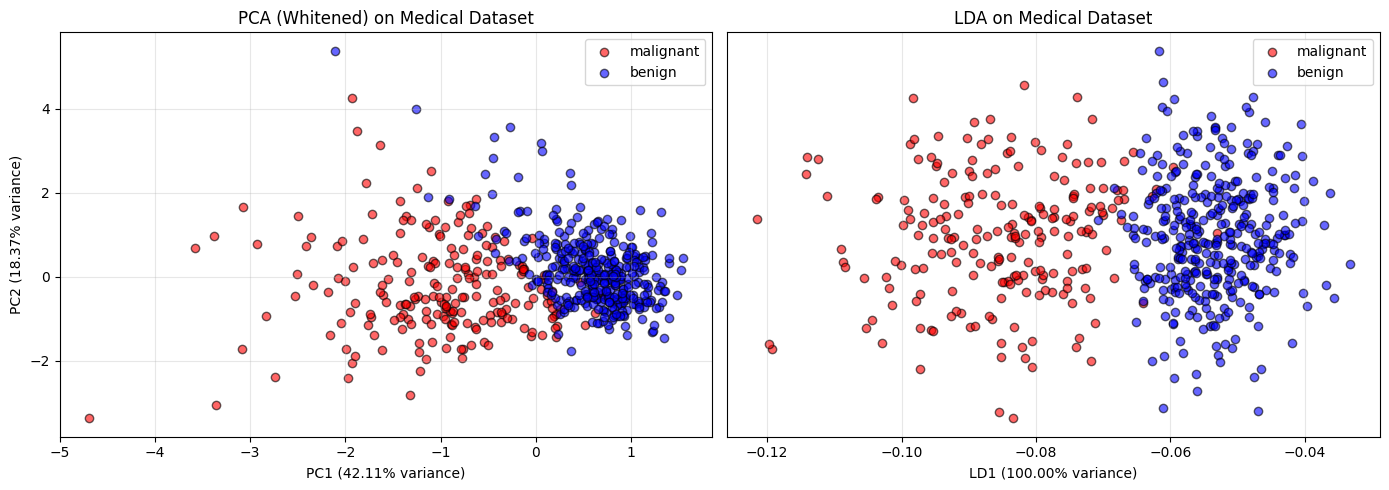

In [6]:
# ==========================================
# VISUALIZATION
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot PCA
colors = ['red', 'blue']
for i, color in enumerate(colors):
    axes[0].scatter(X_pca[y_medical == i, 0], X_pca[y_medical == i, 1], 
                    c=color, label=target_names[i], alpha=0.6, edgecolors='k')
axes[0].set_title("PCA (Whitened) on Medical Dataset")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot LDA (1D projection spread out on Y-axis for visibility)
for i, color in enumerate(colors):
    axes[1].scatter(X_lda[y_medical == i, 0], np.random.normal(0, 0.1, sum(y_medical == i)), 
                    c=color, label=target_names[i], alpha=0.6, edgecolors='k')
axes[1].set_title("LDA on Medical Dataset")
axes[1].set_xlabel(f"LD1 ({lda.explained_variance_ratio_[0]:.2%} variance)")
axes[1].set_yticks([])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()